# 02 Baseline Model — Combined Dataset (Math + Portuguese)

Train a pass/fail classifier on the combined UCI student performance datasets. Steps: load combined data, split train/validation, build preprocessing (one-hot for categoricals, passthrough numeric), train baselines, evaluate, and persist the Random Forest pipeline.


In [21]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# Ensure project root on path
base_dir = Path("../..").resolve()
sys.path.append(str(base_dir))

pd.set_option("display.max_columns", None)
processed_dir = base_dir / "data" / "processed" / "performance"
models_dir = base_dir / "models" / "performance"
models_dir.mkdir(parents=True, exist_ok=True)


In [22]:
# Load cleaned datasets and combine them if needed
mat_path = processed_dir / "student_mat_cleaned.csv"
por_path = processed_dir / "student_por_cleaned.csv"
combined_path = processed_dir / "student_all_cleaned.csv"

if combined_path.exists():
    df = pd.read_csv(combined_path)
else:
    mat_df = pd.read_csv(mat_path).assign(dataset="math")
    por_df = pd.read_csv(por_path).assign(dataset="portuguese")
    df = pd.concat([mat_df, por_df], ignore_index=True)
    df.to_csv(combined_path, index=False)

print(df.shape)
df.head()


(1044, 35)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,pass,dataset
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,1,math
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,1,math
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,1,math


In [23]:
# Separate features/target
X = df.drop(columns=["G3", "pass"])
y = df["pass"]

cat_cols = list(X.select_dtypes(include=["object", "string"]).columns)
num_cols = list(X.select_dtypes(exclude=["object", "string"]).columns)
cat_cols, num_cols

(['school',
  'sex',
  'address',
  'famsize',
  'Pstatus',
  'Mjob',
  'Fjob',
  'reason',
  'guardian',
  'schoolsup',
  'famsup',
  'paid',
  'activities',
  'nursery',
  'higher',
  'internet',
  'romantic',
  'dataset'],
 ['age',
  'Medu',
  'Fedu',
  'traveltime',
  'studytime',
  'failures',
  'famrel',
  'freetime',
  'goout',
  'Dalc',
  'Walc',
  'health',
  'absences',
  'G1',
  'G2'])

In [24]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [25]:
# Preprocessing: one-hot encode categoricals, passthrough numerics
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols),
    ]
)

In [26]:
# Baseline 1: Logistic Regression
log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            LogisticRegression(max_iter=500, class_weight="balanced"),
        ),
    ]
)
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_val)
print("Logistic Regression report:\n", classification_report(y_val, log_pred))
print("Confusion matrix:\n", confusion_matrix(y_val, log_pred))

Logistic Regression report:
               precision    recall  f1-score   support

           0       0.68      0.85      0.76        46
           1       0.95      0.89      0.92       163

    accuracy                           0.88       209
   macro avg       0.82      0.87      0.84       209
weighted avg       0.89      0.88      0.88       209

Confusion matrix:
 [[ 39   7]
 [ 18 145]]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_linea

In [27]:
# Baseline 2: Random Forest
rf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        (
            "model",
            RandomForestClassifier(
                n_estimators=700,
                random_state=42,
                class_weight="balanced",  # balance classes
                n_jobs=-1,
                max_depth=None,
                min_samples_leaf=2,
            ),
        ),
    ]
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
print("Random Forest report:\n", classification_report(y_val, rf_pred))
print("Confusion matrix:\n", confusion_matrix(y_val, rf_pred))

Random Forest report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80        46
           1       0.96      0.92      0.94       163

    accuracy                           0.90       209
   macro avg       0.85      0.88      0.87       209
weighted avg       0.91      0.90      0.91       209

Confusion matrix:
 [[ 39   7]
 [ 13 150]]


In [28]:
# Choose a model to persist (random forest) and save
best_model = rf
model_path = models_dir / "pass_classifier_rf.joblib"
joblib.dump(best_model, model_path)
print(f"Saved model to {model_path}")


Saved model to /Users/admin/Documents/GitHub/Student Dropout Prediction and Alert System/models/performance/pass_classifier_rf.joblib


### Notes
- Dataset: combined math + Portuguese cleaned records (1044 rows).
- Random Forest currently performs best; tune hyperparameters or thresholds if recall needs to be higher.
- To switch to regression, set `y = df["G3"]`, remove class weights, and use a regressor with MAE/RMSE metrics.


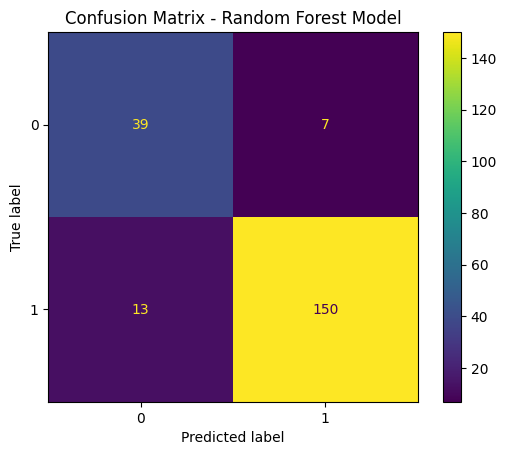

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Use validation set (not X_test)
y_pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Random Forest Model")
plt.savefig("confusion_matrix.png")
plt.show()